# Modelado Predictivo: SARIMA
Este notebook entrena un modelo Seasonal ARIMA para la zona más transitada.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_parquet('../datos/procesados/demanda_top10_series_tiempo.parquet')
# Aislar Upper East Side South
df_zone = df[df['PULocationID'] == 237][['hora', 'total_viajes']].copy()
df_zone.set_index('hora', inplace=True)
df_zone.sort_index(inplace=True)
# Train/Test Split (7 días test)
train_size = len(df_zone) - (7 * 24)
train = df_zone.iloc[:train_size]
test = df_zone.iloc[train_size:]

## Entrenamiento del Modelo SARIMA
Entrenamos con S=24 (estacionalidad diaria).

In [13]:
print('Entrenando SARIMA (esto puede tomar 1-2 minutos)...')
modelo_sarima = SARIMAX(train['total_viajes'], order=(1,0,1), seasonal_order=(1,0,1,24))
resultado_sarima = modelo_sarima.fit(disp=False)
print('¡Entrenamiento Completado!')

Entrenando SARIMA (esto puede tomar 1-2 minutos)...
¡Entrenamiento Completado!


In [14]:
pred_sarima = resultado_sarima.predict(start=len(train), end=len(df_zone)-1)
mae = mean_absolute_error(test['total_viajes'], pred_sarima)
rmse = np.sqrt(mean_squared_error(test['total_viajes'], pred_sarima))
print(f'MAE SARIMA: {mae:.2f}')
print(f'RMSE SARIMA: {rmse:.2f}')

MAE SARIMA: 59.06
RMSE SARIMA: 76.11


## Diagnóstico del Modelo SARIMA
Como analistas, no basta con ver el error, debemos ver *dónde* se equivoca el modelo. SARIMA asume que los errores (residuales) deben comportarse como ruido blanco aleatorio. Si hay patrones en los errores, el modelo falló en capturar algo.

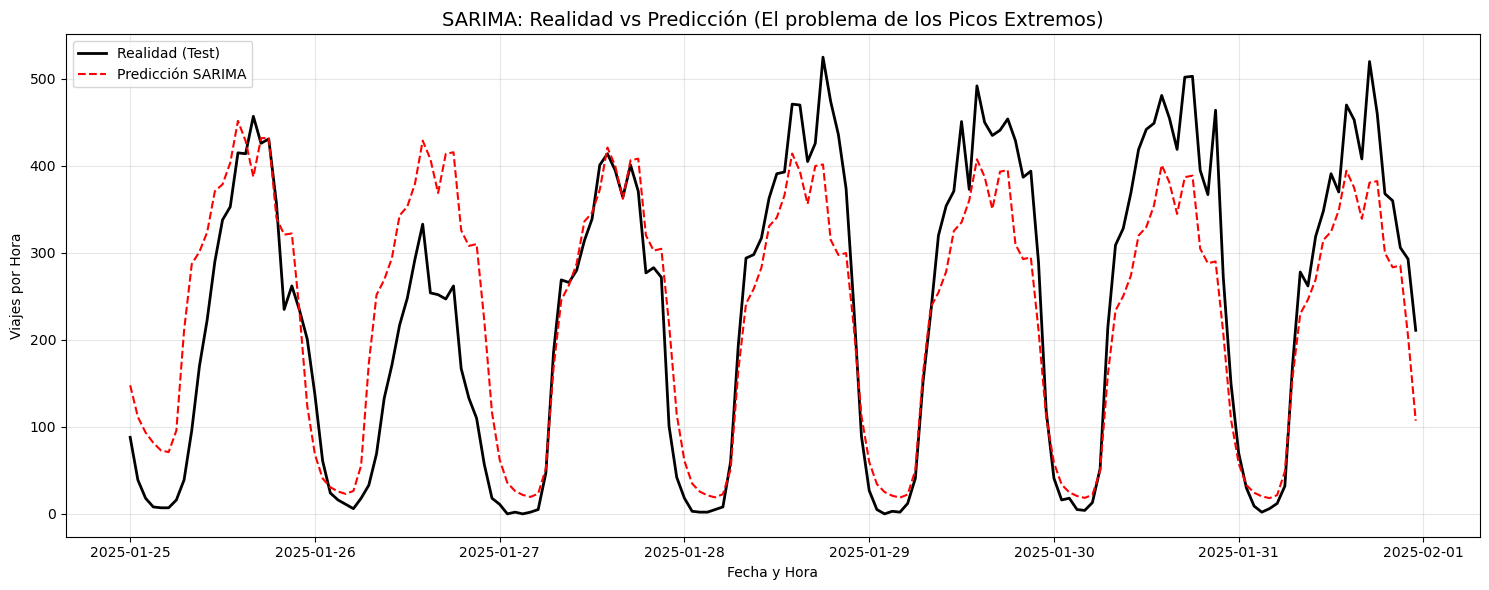

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gráfico de Predicción vs Realidad (Zoom a los últimos 7 días)
plt.figure(figsize=(15, 6))
plt.plot(test.index, test['total_viajes'], label='Realidad (Test)', color='black', linewidth=2)
plt.plot(test.index, pred_sarima, label='Predicción SARIMA', color='red', linestyle='--')
plt.title('SARIMA: Realidad vs Predicción (El problema de los Picos Extremos)', fontsize=14)
plt.xlabel('Fecha y Hora')
plt.ylabel('Viajes por Hora')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

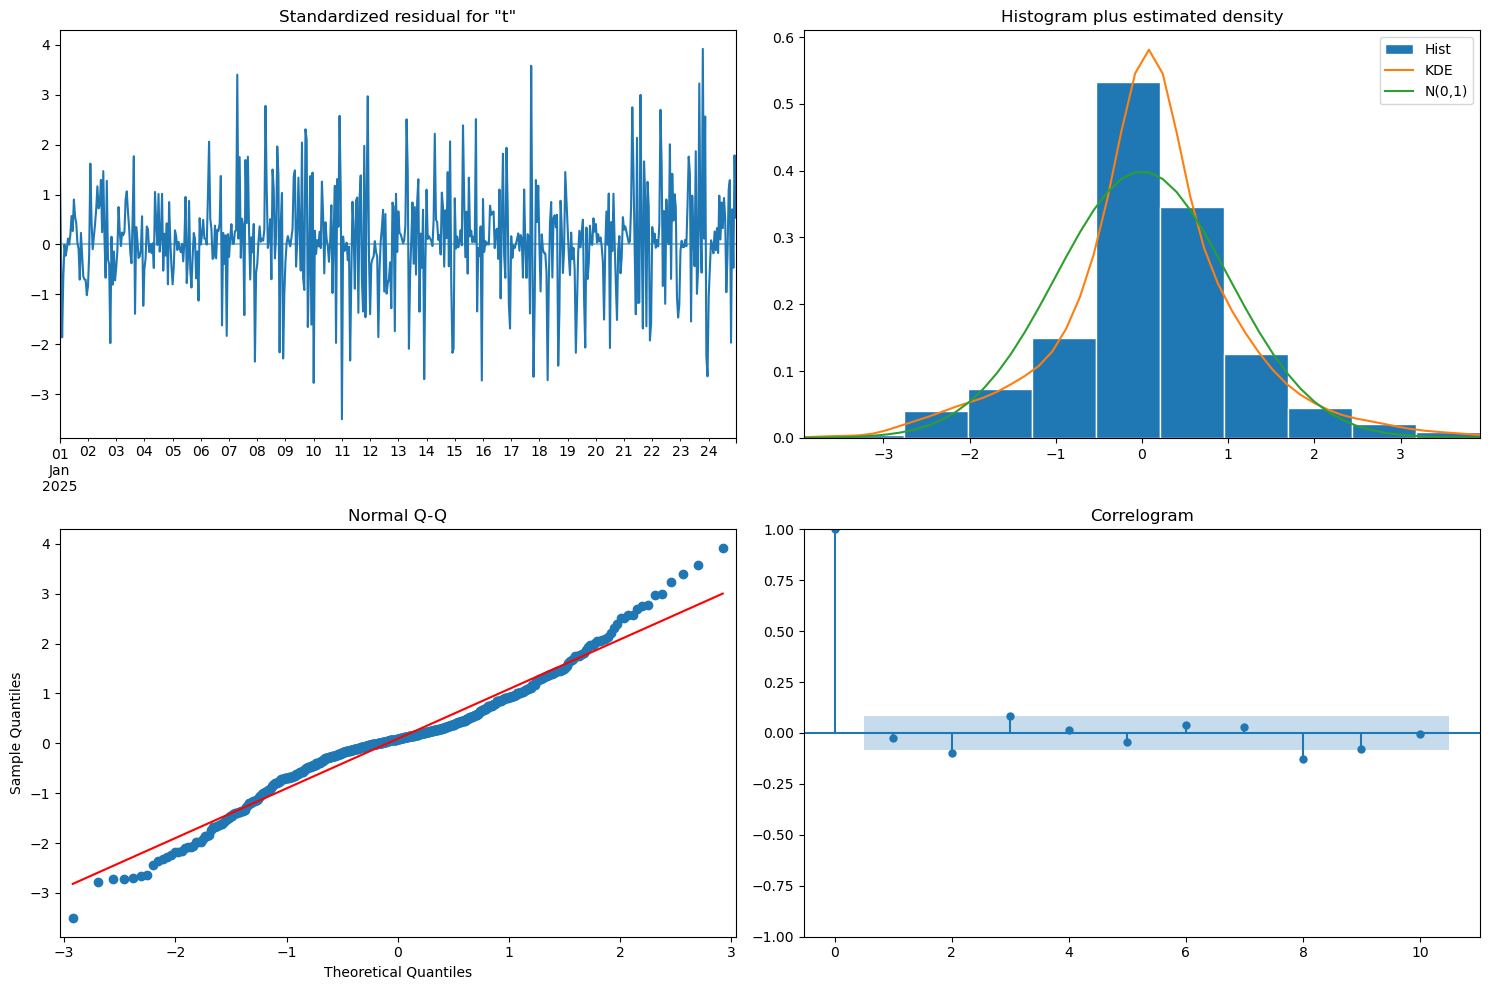

In [16]:
# 2. Gráfico de Diagnóstico de Residuales
resultado_sarima.plot_diagnostics(figsize=(15, 10))
plt.tight_layout()
plt.show()

Este panel de 4 gráficas es la prueba reina en econometría. El correlograma (abajo a la derecha) demuestra que la mayoría de los puntos azules están dentro de la zona celeste permitida, lo que indica que el modelo sí logró exprimir matemáticamente la serie de tiempo. Pero el histograma (arriba a la derecha) revela "colas pesadas"; esto confirma que los eventos anómalos de Nueva York no siguen una distribución normal tradicional, y por eso SARIMA se confunde en los extremos.